<a href="https://colab.research.google.com/github/NoorAlHuda-afk/Predictive-Model-for-Breast-Cancer-Diagnosis/blob/main/source_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Essential Libraries**

In [43]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, recall_score, precision_score
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# 1. Data Exploration and Wrangling

### 1.1 Load the dataset from UCI

In [44]:
# Define the column names exactly as they appear in the dataset documentation
column_names = [
    'Sample_code_number', 'Clump_thickness', 'Uniformity_of_cell_size',
    'Uniformity_of_cell_shape', 'Marginal_adhesion', 'Single_epithelial_cell_size',
    'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses', 'Class'
]

# URL to the breast-cancer-wisconsin.data file
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'

# Load the data into a Pandas DataFrame
df = pd.read_csv(url, header=None, names=column_names, na_values='?')

print(f"Initial dataset shape: {df.shape}")

Initial dataset shape: (699, 11)


### 1.2 Data Cleaning

In [45]:
# Check for missing values (coded as '?')
print("\n Missing Values Before Handling: ")
print(df.isnull().sum())

# Drop rows with missing values
df_clean = df.dropna()
print(f"\nDataset shape after dropping rows with missing values: {df_clean.shape}")

# Convert 'Class' values to a more standard binary format: Benign=0, Malignant=1
# Original values: 2 for benign, 4 for malignant
df_clean['Class'] = df_clean['Class'].map({2: 0, 4: 1})

print("\n Class Distribution After Encoding: ")
print(df_clean['Class'].value_counts())
print("(0 = Benign, 1 = Malignant)")

# Drop the ID column and the target column to get the features (separate feature (x) and target (y))
X = df_clean.drop(['Sample_code_number', 'Class'], axis=1)
y = df_clean['Class']

print(f"\nFinal Feature set shape: {X.shape}")
print(f"Final Target set shape: {y.shape}")


 Missing Values Before Handling: 
Sample_code_number              0
Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

Dataset shape after dropping rows with missing values: (683, 11)

 Class Distribution After Encoding: 
Class
0    444
1    239
Name: count, dtype: int64
(0 = Benign, 1 = Malignant)

Final Feature set shape: (683, 9)
Final Target set shape: (683,)


/tmp/ipykernel_6510/2674844983.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Class'] = df_clean['Class'].map({2: 0, 4: 1})


### 1.3 Examine basic statistics of the data

In [46]:
print("\nBasic Statistics of Features:")
print(df_clean.describe())


Basic Statistics of Features:
       Sample_code_number  Clump_thickness  Uniformity_of_cell_size  \
count        6.830000e+02       683.000000               683.000000   
mean         1.076720e+06         4.442167                 3.150805   
std          6.206440e+05         2.820761                 3.065145   
min          6.337500e+04         1.000000                 1.000000   
25%          8.776170e+05         2.000000                 1.000000   
50%          1.171795e+06         4.000000                 1.000000   
75%          1.238705e+06         6.000000                 5.000000   
max          1.345435e+07        10.000000                10.000000   

       Uniformity_of_cell_shape  Marginal_adhesion  \
count                683.000000         683.000000   
mean                   3.215227           2.830161   
std                    2.988581           2.864562   
min                    1.000000           1.000000   
25%                    1.000000           1.000000   
50%  

###  1.4 A Detailed Summary

In [47]:
print("Key Findings from Initial Exploration:")
print("="*60)
print(f"1. The dataset initially had {df.shape[0]} samples. After handling missing values, we have {df_clean.shape[0]} complete samples.")
print(f"2. The target variable is imbalanced: {y.sum()} malignant cases out of {len(y)} total cases.")
print(f"3. Feature scales are comparable (all 1-10), but standardization is still a good practice for many models.")
print("4. A primary task is to use the 9 cytological features to predict the 'Class' (Benign/Malignant).")

Key Findings from Initial Exploration:
1. The dataset initially had 699 samples. After handling missing values, we have 683 complete samples.
2. The target variable is imbalanced: 239 malignant cases out of 683 total cases.
3. Feature scales are comparable (all 1-10), but standardization is still a good practice for many models.
4. A primary task is to use the 9 cytological features to predict the 'Class' (Benign/Malignant).


- Most features have a **median of 1 or 2**, but means are higher (e.g., `Clump_thickness` mean=4.44, median=4).

- **Standard deviations** are large (2–3), indicating wide variability among samples.

- `Mitoses` has the lowest mean (1.60) and median (1) – most tumors show rare mitotic activity.

- No extreme outliers beyond the natural 1–10 range.

# 2. Build & Evaluate Classification Models

In [48]:
# Split the data (stratify preserves class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (important for SVM & Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine (SVC)': SVC(kernel='rbf', probability=True, random_state=42)
}

# Train and evaluate each model
print("="*60)
print("Model Performance on Breast Cancer Malignancy Prediction")
print("="*60)

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

    # Metrics
    print(f"\n--- {name} ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))
    if y_prob is not None:
        auc = roc_auc_score(y_test, y_prob)
        print(f"ROC-AUC Score: {auc:.3f}")

    # Cross-validation (adds robustness)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    print(f"5-Fold CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Feature importance (for Random Forest)
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X.columns
print("\n" + "="*60)
print("Random Forest Feature Importance")
print("="*60)
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"{name:30}: {imp:.3f}")

Model Performance on Breast Cancer Malignancy Prediction

--- Logistic Regression ---
[[85  4]
 [ 1 47]]
              precision    recall  f1-score   support

      Benign       0.99      0.96      0.97        89
   Malignant       0.92      0.98      0.95        48

    accuracy                           0.96       137
   macro avg       0.95      0.97      0.96       137
weighted avg       0.96      0.96      0.96       137

ROC-AUC Score: 0.992
5-Fold CV Accuracy: 0.971 (+/- 0.007)

--- Random Forest ---
[[85  4]
 [ 2 46]]
              precision    recall  f1-score   support

      Benign       0.98      0.96      0.97        89
   Malignant       0.92      0.96      0.94        48

    accuracy                           0.96       137
   macro avg       0.95      0.96      0.95       137
weighted avg       0.96      0.96      0.96       137

ROC-AUC Score: 0.984
5-Fold CV Accuracy: 0.972 (+/- 0.016)

--- Support Vector Machine (SVC) ---
[[85  4]
 [ 1 47]]
              precision 

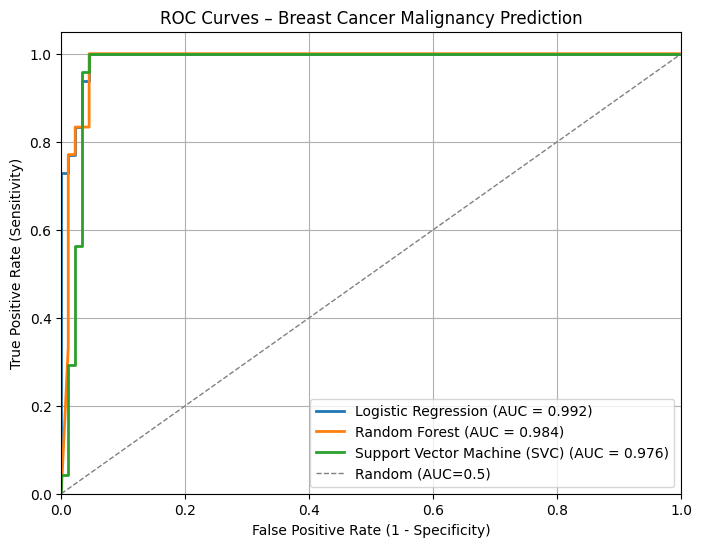

In [49]:
from sklearn.metrics import auc, roc_curve

plt.figure(figsize=(8, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC=0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves – Breast Cancer Malignancy Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 3. Clinical Threshold Tuning

Current threshold (default): 0.50 → Sensitivity = 0.979
Threshold to achieve ≥99% sensitivity: 0.248
At threshold 0.248: Sensitivity = 1.000, Specificity = 0.955
False Positives (benign flagged as malignant): 4 out of 89 benign cases


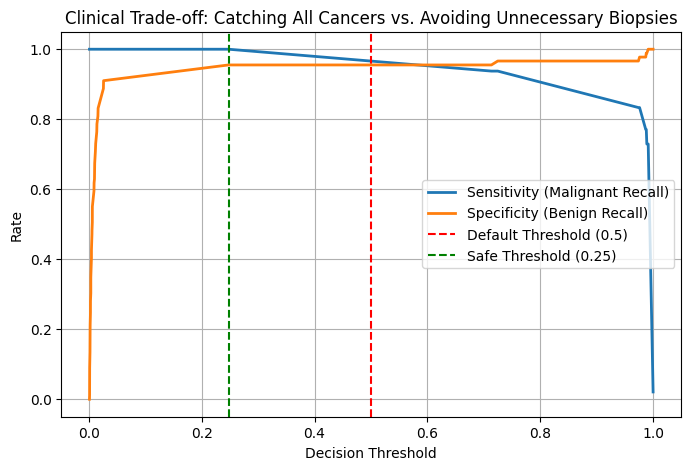

In [50]:
# Threshold optimization for clinical safety

lr_best = LogisticRegression(random_state=42)
lr_best.fit(X_train_scaled, y_train)
y_probs = lr_best.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calculate metrics for each threshold
sensitivities = []
specificities = []
for thresh in thresholds:
    y_pred_thresh = (y_probs >= thresh).astype(int)
    sens = recall_score(y_test, y_pred_thresh)  # malignant recall
    spec = recall_score(y_test, y_pred_thresh, pos_label=0)  # benign recall
    sensitivities.append(sens)
    specificities.append(spec)

# Find threshold that gives sensitivity >= 0.99 (catch 99% of cancers)
safe_threshold = None
for thresh, sens in zip(thresholds, sensitivities):
    if sens >= 0.99:
        safe_threshold = thresh
        break

print(f"Current threshold (default): 0.50 → Sensitivity = {recall_score(y_test, (y_probs >= 0.5).astype(int)):.3f}")
if safe_threshold:
    print(f"Threshold to achieve ≥99% sensitivity: {safe_threshold:.3f}")
    y_pred_safe = (y_probs >= safe_threshold).astype(int)
    sens_safe = recall_score(y_test, y_pred_safe)
    spec_safe = recall_score(y_test, y_pred_safe, pos_label=0)
    fp_safe = sum((y_pred_safe == 1) & (y_test == 0))
    print(f"At threshold {safe_threshold:.3f}: Sensitivity = {sens_safe:.3f}, Specificity = {spec_safe:.3f}")
    print(f"False Positives (benign flagged as malignant): {fp_safe} out of {sum(y_test==0)} benign cases")
else:
    print("No threshold yields ≥99% sensitivity in this test set (likely already near perfect).")

# Plot sensitivity vs specificity trade-off
plt.figure(figsize=(8,5))
plt.plot(thresholds, sensitivities, label='Sensitivity (Malignant Recall)', linewidth=2)
plt.plot(thresholds, specificities, label='Specificity (Benign Recall)', linewidth=2)
plt.axvline(x=0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
if safe_threshold:
    plt.axvline(x=safe_threshold, color='green', linestyle='--', label=f'Safe Threshold ({safe_threshold:.2f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Rate')
plt.title('Clinical Trade-off: Catching All Cancers vs. Avoiding Unnecessary Biopsies')
plt.legend()
plt.grid(True)
plt.show()

## Decision Curve Analysis

/tmp/ipykernel_6510/2711373497.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  benefit = (tp / n) - (fp / n) * (threshold / (1 - threshold))
/tmp/ipykernel_6510/2711373497.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  benefit = (tp / n) - (fp / n) * (threshold / (1 - threshold))
/tmp/ipykernel_6510/2711373497.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  nb_all = [ (sum(y_test)/len(y_test)) - (th/(1-th))*(1 - sum(y_test)/len(y_test))


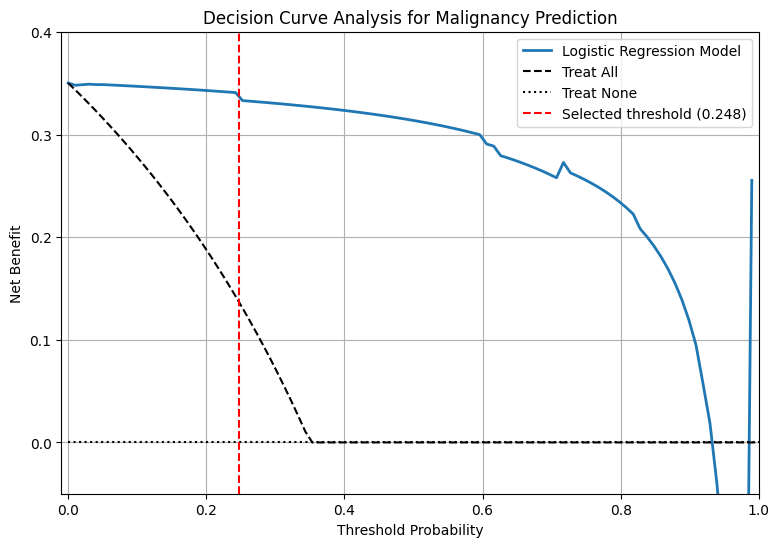

Net benefit at threshold 0.248: 0.3334


In [51]:
def net_benefit(y_true, y_prob, threshold):
    """Calculate net benefit at a given threshold."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    n = len(y_true)
    # Net benefit = (true positives / n) - (false positives / n) * (threshold/(1-threshold))
    benefit = (tp / n) - (fp / n) * (threshold / (1 - threshold))
    return benefit

# Probabilities from Logistic Regression
y_probs = lr_best.predict_proba(X_test_scaled)[:, 1]
thresholds = np.linspace(0, 1, 100)

# Net benefit for model
nb_model = [net_benefit(y_test, y_probs, th) for th in thresholds]

# Net benefit for "treat all" (everyone is malignant)
nb_all = [ (sum(y_test)/len(y_test)) - (th/(1-th))*(1 - sum(y_test)/len(y_test))
           for th in thresholds ]
nb_all = np.maximum(nb_all, 0)  # net benefit cannot be negative in practice

# Net benefit for "treat none"
nb_none = [0] * len(thresholds)

# Plot
plt.figure(figsize=(9,6))
plt.plot(thresholds, nb_model, label='Logistic Regression Model', linewidth=2)
plt.plot(thresholds, nb_all, 'k--', label='Treat All', linewidth=1.5)
plt.plot(thresholds, nb_none, 'k:', label='Treat None', linewidth=1.5)

# Chosen threshold (0.248)
plt.axvline(x=0.248, color='red', linestyle='--', label='Selected threshold (0.248)')

plt.xlabel('Threshold Probability')
plt.ylabel('Net Benefit')
plt.title('Decision Curve Analysis for Malignancy Prediction')
plt.legend(loc='best')
plt.grid(True)
plt.xlim(-0.01, 1)
plt.ylim(-0.05, max(nb_model)+0.05)
plt.show()

nb_at_threshold = net_benefit(y_test, y_probs, 0.248)
print(f"Net benefit at threshold 0.248: {nb_at_threshold:.4f}")

## Calibration Plot

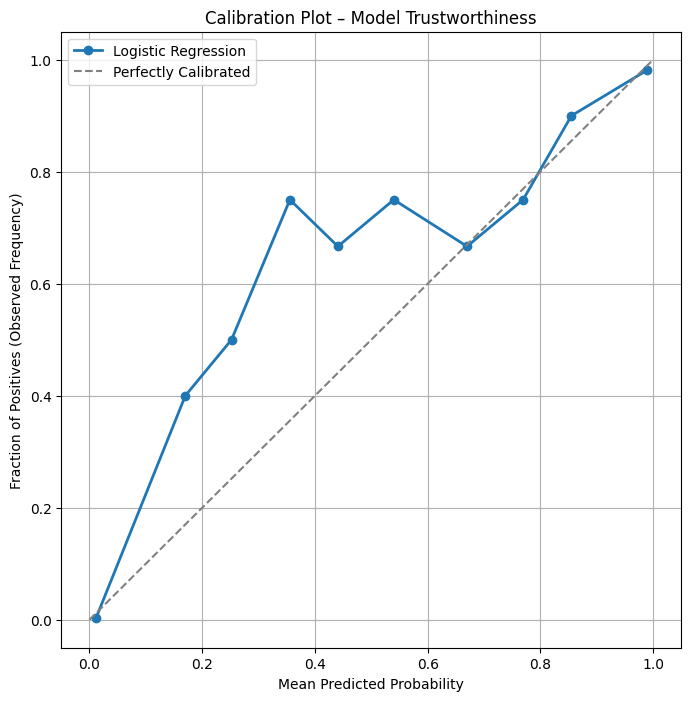

Brier Score: 0.0210 (0 = perfect, >0.2 = poor)


In [52]:
# Get predicted probabilities on the entire cleaned dataset (re-fit for all data)
lr_full = LogisticRegression(random_state=42)
X_full_scaled = scaler.fit_transform(X)  # use full X
lr_full.fit(X_full_scaled, y)
y_full_probs = lr_full.predict_proba(X_full_scaled)[:, 1]

# Compute calibration curve (fraction of positives per bin)
prob_true, prob_pred = calibration_curve(y, y_full_probs, n_bins=10)

# Plot
plt.figure(figsize=(8,8))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Observed Frequency)')
plt.title('Calibration Plot – Model Trustworthiness')
plt.legend()
plt.grid(True)
plt.show()

# Brier score (lower is better)
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y, y_full_probs)
print(f"Brier Score: {brier:.4f} (0 = perfect, >0.2 = poor)")